In [1]:
#SANITY CHECK v11
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import gc
import os
import math

from unet3d_3 import UNet3D
from luna16_dataset_and_dataloader import create_patch_dataloaders

gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_DIR= "/home/jovyan/vol.2/unet_patches_vol.2"
BATCH_SIZE= 4
NUM_WORKERS= 2
POSITIVE_FRACTION  = 0.75
INIT_FEATURES = 48
DROPOUT= 0.2
COVARIANCE_DROPOUT = 0.2
POS_WEIGHT= 10.0
USE_AMP= True

class ChannelAwareFocalLoss(nn.Module):
    def __init__(self, base_pos_weight=10.0, alpha=0.75, gamma=2.0):
        super().__init__()
        self.base_pos_weight = base_pos_weight
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets, channel_importances):
        all_imp  = torch.stack([imp.mean() for imp in channel_importances])
        mean_imp = all_imp.mean()
        dyn_pw   = self.base_pos_weight * (1.0 + mean_imp)
        pw_tensor = torch.tensor([dyn_pw.item()], device=inputs.device)
        bce = F.binary_cross_entropy_with_logits(inputs, targets, pos_weight=pw_tensor, reduction='none')
        pt  = torch.exp(-bce.detach())
        loss = torch.mean(self.alpha * (1 - pt) ** self.gamma * bce)
        return loss, dyn_pw.item()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predict, target):
        predict = torch.sigmoid(predict).view(-1)
        target  = target.view(-1)
        intersection = (predict * target).sum()
        return 1 - (2. * intersection + self.smooth) / (predict.sum() + target.sum() + self.smooth)


_ca_focal = ChannelAwareFocalLoss(base_pos_weight=POS_WEIGHT)
_dice = DiceLoss()


def sanity_combined_loss(pred, target, importances):
    pw_static = torch.tensor([POS_WEIGHT], device=pred.device)
    bce_loss  = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pw_static)
    focal_loss, dpw = _ca_focal(pred, target, importances)
    dice_loss  = _dice(pred, target)
    combined   = 0.4 * bce_loss + 0.35 * focal_loss + 0.25 * dice_loss
    return combined, bce_loss.item(), focal_loss.item(), dice_loss.item(), dpw

def calculate_batch_metrics(predictions, targets, threshold=0.5):
    with torch.no_grad():
        probs  = torch.sigmoid(predictions)
        binary = (probs > threshold).float().view(-1)
        tgt    = targets.view(-1)
        flat_probs = probs.view(-1)

        TP = ((binary == 1) & (tgt == 1)).sum().float()
        FP = ((binary == 1) & (tgt == 0)).sum().float()
        FN = ((binary == 0) & (tgt == 1)).sum().float()
        TN = ((binary == 0) & (tgt == 0)).sum().float()

        recall = TP / (TP + FN + 1e-8)
        precision = TP / (TP + FP + 1e-8)
        dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
        specificity = TN / (TN + FP + 1e-8)
        npv = TN / (TN + FN + 1e-8)
        mcc_num= TP * TN - FP * FN
        mcc_den= ((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)).sqrt()
        mcc = mcc_num / (mcc_den + 1e-8)
        beta = 2.0
        f2  = (1 + beta**2) * precision * recall / (beta**2 * precision + recall + 1e-8)
        soft_recall = (flat_probs * tgt).sum() / (tgt.sum() + 1e-8)
        pos_mask = tgt == 1
        mean_pos_prob = flat_probs[pos_mask].mean() if pos_mask.any() else torch.tensor(0.0)
        mean_neg_prob = flat_probs[~pos_mask].mean() if (~pos_mask).any() else torch.tensor(0.0)

    return {
        'TP': TP.item(), 'FP': FP.item(), 'FN': FN.item(), 'TN': TN.item(),
        'recall':        recall.item(),
        'precision':     precision.item(),
        'dice':          dice.item(),
        'specificity':   specificity.item(),
        'npv':           npv.item(),
        'mcc':           mcc.item(),
        'f2':            f2.item(),
        'soft_recall':   soft_recall.item(),
        'mean_pos_prob': mean_pos_prob.item(),
        'mean_neg_prob': mean_neg_prob.item(),
    }


print("Loading data for sanity check...")
train_loader, _, _ = create_patch_dataloaders(
    patch_dir=PATCH_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    positive_fraction=POSITIVE_FRACTION,
)

sanity_model = UNet3D(
    input_channels=1,
    output_channels=1,
    init_features=INIT_FEATURES,
    dropout=DROPOUT,
    checkpointing=False,
    covariance_dropout=COVARIANCE_DROPOUT,
).to(device)

n_params = sum(p.numel() for p in sanity_model.parameters() if p.requires_grad)
print(f"Model params: {n_params/1e6:.2f}M  |  device: {device}")
print(f"covariance_dropout: {COVARIANCE_DROPOUT}  |  pos_weight: {POS_WEIGHT}\n")


N_EPOCHS  = 5
N_BATCHES = 100

checks = {
    'forward_pass': False,
    'loss_decreasing': False,
    'importance_moving': False,
    'recall_nonzero': False,
    'no_oom': False,
}

importance_params = [
    p for n, p in sanity_model.named_parameters()
    if 'channel_importance_raw' in n]
base_params = [
    p for n, p in sanity_model.named_parameters()
    if 'channel_importance_raw' not in n]

opt = optim.AdamW([
    {'params': base_params,       'lr': 5e-5,  'weight_decay': 1e-5},
    {'params': importance_params, 'lr': 5e-3,  'weight_decay': 0.0},
], betas=(0.9, 0.999), eps=1e-8)

sc = GradScaler('cuda', enabled=USE_AMP)
epoch_losses = []   
epoch_bce_losses = []
epoch_focal_losses = []
epoch_dice_losses = []
epoch_recalls = []

imp_before = torch.cat([
    imp.detach().cpu() for imp in sanity_model.get_all_channel_importances()])

print("=" * 70)
print(f"SANITY CHECK  v11")
print(f"Running {N_EPOCHS} epochs × {N_BATCHES} batches...")
print(f"Metrics: combined loss  |  BCE / focal / dice (separate)")
print(f"recall, precision, dice-coeff, specificity, NPV, MCC, F2")
print(f"soft recall, mean pos/neg prob")
print("=" * 70)
delta = 0.0 

try:
    for epoch in range(N_EPOCHS):
        sanity_model.train()
        b_combined = []
        b_bce      = []
        b_focal    = []
        b_dice_l   = []

        b_TP = b_FP = b_FN = b_TN = 0.0
        b_soft_recall   = 0.0
        b_mean_pos_prob = 0.0
        b_mean_neg_prob = 0.0
        n_steps = 0

        for step, batch in enumerate(train_loader):
            if step >= N_BATCHES:
                break

            scans = batch['scan'].to(device, non_blocking=True)
            masks = batch['mask'].to(device, non_blocking=True)

            opt.zero_grad()
            with autocast('cuda', enabled=USE_AMP):
                outputs = sanity_model(scans)
                importances = sanity_model.get_all_channel_importances()
                combined, bce_val, focal_val, dice_val, dpw = sanity_combined_loss(
                    outputs, masks, importances)

            if torch.isnan(combined):
                raise ValueError("Loss is NaN — check scaling/normalisation")

            if epoch == 0 and step == 0:
                checks['forward_pass'] = True
                print(f"  [OK] Forward pass  — output shape: {outputs.shape}")
                print(f"Initial dynamic pos_weight: {dpw:.2f}")
                gate = sanity_model.decoder4.attention_gate
                print(f"Covariance dropout p={gate.cov_dropout.p}\n")

            sc.scale(combined).backward()
            sc.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(sanity_model.parameters(), 1.0)
            sc.step(opt)
            sc.update()

            b_combined.append(combined.item())
            b_bce.append(bce_val)
            b_focal.append(focal_val)
            b_dice_l.append(dice_val)

            m = calculate_batch_metrics(outputs, masks)
            b_TP += m['TP'];b_FP += m['FP']
            b_FN += m['FN'];b_TN += m['TN']
            b_soft_recall   += m['soft_recall']
            b_mean_pos_prob += m['mean_pos_prob']
            b_mean_neg_prob += m['mean_neg_prob']
            n_steps += 1

        ep_combined = sum(b_combined) / len(b_combined)
        ep_bce = sum(b_bce)/ len(b_bce)
        ep_focal= sum(b_focal)/ len(b_focal)
        ep_dice_l = sum(b_dice_l)/ len(b_dice_l)

        ep_recall = b_TP / (b_TP + b_FN + 1e-8)
        ep_precision = b_TP / (b_TP + b_FP + 1e-8)
        ep_dice= (2 * b_TP) / (2 * b_TP + b_FP + b_FN + 1e-8)
        ep_specificity = b_TN / (b_TN + b_FP + 1e-8)
        ep_npv= b_TN / (b_TN + b_FN + 1e-8)
        ep_mcc_num = b_TP * b_TN - b_FP * b_FN
        ep_mcc_den = ((b_TP + b_FP) * (b_TP + b_FN) * (b_TN + b_FP) * (b_TN + b_FN)) ** 0.5
        ep_mcc = ep_mcc_num / (ep_mcc_den + 1e-8)
        beta = 2.0
        ep_f2 = (1 + beta**2) * ep_precision * ep_recall / (beta**2 * ep_precision + ep_recall + 1e-8)
        ep_soft_recall   = b_soft_recall/ n_steps
        ep_mean_pos_prob = b_mean_pos_prob / n_steps
        ep_mean_neg_prob = b_mean_neg_prob / n_steps

        epoch_losses.append(ep_combined)
        epoch_bce_losses.append(ep_bce)
        epoch_focal_losses.append(ep_focal)
        epoch_dice_losses.append(ep_dice_l)
        epoch_recalls.append(ep_recall)

        imp_means = [f"{i.mean().item():.4f}" for i in sanity_model.get_all_channel_importances()]
        imp_stds  = [f"{i.std().item():.4f}"  for i in sanity_model.get_all_channel_importances()]

        print(f"\n  Epoch {epoch+1}/{N_EPOCHS}")
        print(f"    ── losses ──────────────────────────────")
        print(f"    {'Combined':<18} {ep_combined:>10.4f}   (0.4·BCE + 0.35·Focal + 0.25·Dice)")
        print(f"    {'  BCE (×0.4)':<18} {ep_bce:>10.4f}   weighted contrib: {0.4*ep_bce:.4f}")
        print(f"    {'  Focal (×0.35)':<18} {ep_focal:>10.4f}   weighted contrib: {0.35*ep_focal:.4f}")
        print(f"    {'  Dice (×0.25)':<18} {ep_dice_l:>10.4f}   weighted contrib: {0.25*ep_dice_l:.4f}")
        print(f"    ── classification ──────────────────────")
        print(f"    {'Recall':<18} {ep_recall:>10.4f}")
        print(f"    {'Precision':<18} {ep_precision:>10.4f}")
        print(f"    {'Dice coeff':<18} {ep_dice:>10.4f}")
        print(f"    {'Specificity':<18} {ep_specificity:>10.4f}")
        print(f"    {'NPV':<18} {ep_npv:>10.4f}")
        print(f"    {'MCC':<18} {ep_mcc:>10.4f}")
        print(f"    {'F2 score':<18} {ep_f2:>10.4f}   (recall-weighted F-beta)")
        print(f"    ── calibration ─────────────────────────")
        print(f"    {'Soft recall':<18} {ep_soft_recall:>10.4f}   (prob mass on positives)")
        print(f"    {'Mean prob | pos':<18} {ep_mean_pos_prob:>10.4f}   (want: high)")
        print(f"    {'Mean prob | neg':<18} {ep_mean_neg_prob:>10.4f}   (want: low)")
        print(f"    ── attention ───────────────────────────")
        print(f"    imp_means: [{' | '.join(imp_means)}]")
        print(f"    imp_stds:  [{' | '.join(imp_stds)}]")

    checks['no_oom'] = True

    if epoch_losses[-1] < epoch_losses[0]:
        checks['loss_decreasing'] = True

    imp_after = torch.cat([
        imp.detach().cpu() for imp in sanity_model.get_all_channel_importances()])
    delta = (imp_after - imp_before).abs().mean().item()
    if delta > 1e-5:
        checks['importance_moving'] = True

    if epoch_recalls[-1] > 0.001:
        checks['recall_nonzero'] = True

except torch.cuda.OutOfMemoryError:
    print("\n  [FAIL] CUDA OOM")
    checks['no_oom'] = False
except Exception as e:
    print(f"\n  [ERROR] {str(e)}")

if epoch_losses:
    print("\n" + "=" * 70)
    print("LOSS TREND SUMMARY  (epoch 1 → last)")
    print("=" * 70)
    def arrow(a, b): return "↓" if b < a else ("↑" if b > a else "→")
    rows = [
        ("Combined", epoch_losses),
        ("BCE", epoch_bce_losses),
        ("Focal",epoch_focal_losses),
        ("Dice", epoch_dice_losses),
    ]
    print(f"  {'Loss':<10}", " ".join(f"E{i+1:>5}" for i in range(len(epoch_losses))))
    for name, vals in rows:
        trend = arrow(vals[0], vals[-1])
        row   = " ".join(f"{v:>6.4f}" for v in vals)
        print(f"  {name:<10} {row}  {trend}")

print("\n" + "=" * 70)
print("SANITY CHECK RESULTS  v11")
print("=" * 70)

messages = {
    'forward_pass':      ("Forward pass runs cleanly + covariance dropout confirmed",
                          "Shape error — check INIT_FEATURES, covariance_dropout param, or input dims"),
    'loss_decreasing':   (f"Combined loss decreasing  {epoch_losses[0]:.4f} → {epoch_losses[-1]:.4f}",
                          f"Combined loss NOT decreasing  {epoch_losses[0] if epoch_losses else 0:.4f} → {epoch_losses[-1] if epoch_losses else 0:.4f}"),
    'importance_moving': (f"channel_importance learning  Δ={delta:.6f}",
                          f"channel_importance FROZEN  Δ={delta:.6f}"),
    'recall_nonzero':    (f"Recall non-zero: {epoch_recalls[-1]:.4f}",
                          f"Recall near zero: {epoch_recalls[-1] if epoch_recalls else 0:.4f}"),
    'no_oom':            ("No OOM error",
                          "OOM detected"),
}

all_passed = True
for key, ok in checks.items():
    tag = "PASS" if ok else "FAIL"
    msg = messages[key][0] if ok else messages[key][1]
    print(f"  [{tag}]  {msg}")
    if not ok:
        all_passed = False

print()
if all_passed:
    print("ALL CHECKS PASSED")
    print("Safe to run full v11 training")
else:
    print("FIX FAILURES ABOVE BEFORE TRAINING")
print("=" * 70)
del sanity_model
gc.collect()
torch.cuda.empty_cache()

Loading data for sanity check...
  TRAIN: 49596 patches  | 30240 positive  | 19356 negative
  VAL  : 7280 patches  | 4392 positive  | 2888 negative
  TEST : 14160 patches  | 8640 positive  | 5520 negative

  Loaders | batch=4 | workers=2 | pos_fraction=0.75
  train=12399 batches | val=1820 | test=3540
Model params: 51.78M  |  device: cuda
covariance_dropout: 0.2  |  pos_weight: 10.0

SANITY CHECK  v11
Running 5 epochs × 100 batches...
Metrics: combined loss  |  BCE / focal / dice (separate)
         recall, precision, dice-coeff, specificity, NPV, MCC, F2
         soft recall, mean pos/neg prob
  [OK] Forward pass  — output shape: torch.Size([4, 1, 96, 96, 96])
       Initial dynamic pos_weight: 15.00
       Covariance dropout p=0.2


  Epoch 1/5
    ── losses ──────────────────────────────
    Combined               0.3463   (0.4·BCE + 0.35·Focal + 0.25·Dice)
      BCE (×0.4)           0.2014   weighted contrib: 0.0806
      Focal (×0.35)        0.0533   weighted contrib: 0.0186
     

In [ ]:
import os
print(os.getcwd())

In [ ]:
import importlib
import unet3d_2
importlib.reload(unet3d_2)
from unet3d_2 import UNet3D
print("UNet3D reloaded")

In [ ]:
import subprocess
import sys
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import os
import gc
from unet3d_3 import UNet3D
from luna16_dataset_and_dataloader import create_patch_dataloaders

gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

#CONFIGURATION
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PATCH_DIR= "/home/jovyan/vol.2/unet_patches_vol.2"
BATCH_SIZE= 4
POSITIVE_FRACTION = 0.75          
NUM_WORKERS = 2
INIT_FEATURES = 48
DROPOUT = 0.2
COVARIANCE_DROPOUT = 0.2
INITIAL_LR = 1e-4
IMPORTANCE_LR = 1e-2
WEIGHT_DECAY = 1e-5
BETAS = (0.9, 0.999)
EPS = 1e-8
POS_WEIGHT = 10.0
LABEL_SMOOTHING = 0.0
ACCUM_STEPS = 4
USE_AMP= True
GRAD_CLIP = 1.0
NUM_EPOCHS = 80
EARLY_STOPPING_PATIENCE = 30
CHECKPOINT_DIR = './checkpoints'

BCE_W = 0.20   
FOCAL_W = 0.30   
DICE_W = 0.50    
FOCAL_ALPHA = 0.85    
SOFT_REC_LAM = 0.15 

os.makedirs(f'{CHECKPOINT_DIR}/all_epochs', exist_ok=True)

#LOSS FUNCTIONS
class ChannelAwareFocalLoss(nn.Module):
    def __init__(self, base_pos_weight: float = 10.0,
                 alpha: float = FOCAL_ALPHA, gamma: float = 2.0):
        super().__init__()
        self.base_pos_weight = base_pos_weight
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets, channel_importances):
        all_imp = torch.stack([imp.mean() for imp in channel_importances])
        mean_imp = all_imp.mean()
        dyn_pw = self.base_pos_weight * (1.0 + mean_imp)
        pw_tensor = torch.tensor([dyn_pw.item()], device=inputs.device)
        bce = F.binary_cross_entropy_with_logits(
            inputs, targets, pos_weight=pw_tensor, reduction='none')
        pt  = torch.exp(-bce.detach())
        return torch.mean(self.alpha * (1 - pt) ** self.gamma * bce), dyn_pw.item()

class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, predict, target):
        predict= torch.sigmoid(predict).view(-1)
        target = target.view(-1)
        intersection = (predict * target).sum()
        return 1 - (2. * intersection + self.smooth) / (
            predict.sum() + target.sum() + self.smooth)

_ca_focal = ChannelAwareFocalLoss(base_pos_weight=POS_WEIGHT)
_dice = DiceLoss()


def combined_loss(pred, target, channel_importances):
    pw_static = torch.tensor([POS_WEIGHT], device=pred.device)

    if LABEL_SMOOTHING > 0:
        smooth_target = target * (1 - LABEL_SMOOTHING) + 0.5 * LABEL_SMOOTHING
        bce = F.binary_cross_entropy_with_logits(pred, smooth_target, pos_weight=pw_static)
    else:
        bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pw_static)

    focal, dyn_pw   = _ca_focal(pred, target, channel_importances)
    dice = _dice(pred, target)
    probs= torch.sigmoid(pred)
    soft_recall = (probs * target).sum() / (target.sum() + 1e-8)
    soft_rec_loss = 1.0 - soft_recall

    total = (BCE_W        * bce
           + FOCAL_W      * focal
           + DICE_W       * dice
           + SOFT_REC_LAM * soft_rec_loss)

    return total, bce.item(), focal.item(), dice.item(), soft_rec_loss.item(), dyn_pw

#METRICS
def calculate_batch_metrics(predictions, targets, threshold=0.5):
    with torch.no_grad():
        probs= torch.sigmoid(predictions)
        binary= (probs > threshold).float().view(-1)
        tgt = targets.view(-1)
        flat_probs = probs.view(-1)

        TP = ((binary == 1) & (tgt == 1)).sum().float()
        FP = ((binary == 1) & (tgt == 0)).sum().float()
        FN = ((binary == 0) & (tgt == 1)).sum().float()
        TN = ((binary == 0) & (tgt == 0)).sum().float()

        recall = TP / (TP + FN + 1e-8)
        precision = TP / (TP + FP + 1e-8)
        dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
        specificity = TN / (TN + FP + 1e-8)
        npv = TN / (TN + FN + 1e-8)
        mcc_num = TP * TN - FP * FN
        mcc_den = ((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)).sqrt()
        mcc = mcc_num / (mcc_den + 1e-8)
        beta = 2.0
        f2   = (1 + beta**2) * precision * recall / (beta**2 * precision + recall + 1e-8)
        soft_recall = (flat_probs * tgt).sum() / (tgt.sum() + 1e-8)

        #calibration
        pos_mask = tgt == 1
        mean_pos_prob = flat_probs[pos_mask].mean()  if pos_mask.any()    else torch.tensor(0.0)
        mean_neg_prob = flat_probs[~pos_mask].mean() if (~pos_mask).any() else torch.tensor(0.0)
        prob_gap = mean_pos_prob - mean_neg_prob  # want this growing across epochs

    return {
        'TP': TP.item(), 'FP': FP.item(), 'FN': FN.item(), 'TN': TN.item(),
        'recall':        recall.item(),
        'precision':     precision.item(),
        'dice':          dice.item(),
        'specificity':   specificity.item(),
        'npv':           npv.item(),
        'mcc':           mcc.item(),
        'f2':            f2.item(),
        'soft_recall':   soft_recall.item(),
        'mean_pos_prob': mean_pos_prob.item(),
        'mean_neg_prob': mean_neg_prob.item(),
        'prob_gap':      prob_gap.item(),
    }
print("=" * 70)
print("U-NET TRAINING  v11")
print("=" * 70)
print(f"  patch_dir        : {PATCH_DIR}")
print(f"  batch_size       : {BATCH_SIZE}  (effective {BATCH_SIZE*ACCUM_STEPS} with accum)")
print(f"  positive_fraction: {POSITIVE_FRACTION}  (unchanged)")
print(f"  optimizer        : AdamW  lr={INITIAL_LR}  importance_lr={IMPORTANCE_LR}  wd={WEIGHT_DECAY}")
print(f"  scheduler        : ReduceLROnPlateau  factor=0.5  patience=3")
print(f"  pos_weight       : {POS_WEIGHT}  (+ dynamic ChannelAware scaling)")
print(f"  focal alpha      : {FOCAL_ALPHA}  (was 0.75)")
print(f"  loss weights     : {BCE_W}·BCE + {FOCAL_W}·Focal + {DICE_W}·Dice + {SOFT_REC_LAM}·SoftRec")
print(f"                     (was 0.40·BCE + 0.35·Focal + 0.25·Dice)")
print(f"  dropout          : {DROPOUT}  |  covariance_dropout: {COVARIANCE_DROPOUT}  |  AMP: {USE_AMP}")
print(f"  epochs           : {NUM_EPOCHS}  |  patience: {EARLY_STOPPING_PATIENCE}")
print(f"  early stopping   : val_recall  |  threshold: 0.5")
print(f"  metrics          : recall, precision, dice, specificity, NPV, MCC,")
print(f"                     F2, soft recall, mean pos/neg prob, prob gap")
print(f"  losses tracked   : combined, BCE, focal, dice, soft-recall term")
print("=" * 70)

# DATA
print("\nLoading datasets...")
train_loader, val_loader, test_loader = create_patch_dataloaders(
    patch_dir=PATCH_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    positive_fraction=POSITIVE_FRACTION,
)

#MODEL
model = UNet3D(
    input_channels=1,
    output_channels=1,
    init_features=INIT_FEATURES,
    dropout=DROPOUT,
    checkpointing=False,
    covariance_dropout=COVARIANCE_DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel params: {n_params/1e6:.2f}M  |  device: {device}")

importance_params = [p for n, p in model.named_parameters() if 'channel_importance_raw' in n]
base_params = [p for n, p in model.named_parameters() if 'channel_importance_raw' not in n]

print(f"  Base params:       {sum(p.numel() for p in base_params)/1e6:.2f}M  lr={INITIAL_LR}")
print(f"  Importance params: {sum(p.numel() for p in importance_params)}  lr={IMPORTANCE_LR}")

optimizer = optim.AdamW([
    {'params': base_params,       'lr': INITIAL_LR,    'weight_decay': WEIGHT_DECAY},
    {'params': importance_params, 'lr': IMPORTANCE_LR, 'weight_decay': 0.0},
], betas=BETAS, eps=EPS)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

scaler = GradScaler(enabled=USE_AMP)

RESUME_FROM = f'{CHECKPOINT_DIR}/last_checkpoint.pth'
start_epoch = 0

if os.path.exists(RESUME_FROM):
    print(f"\nResuming from checkpoint: {RESUME_FROM}")
    checkpoint = torch.load(RESUME_FROM, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    start_epoch = checkpoint['epoch']
    best_val_loss = checkpoint.get('best_val_loss',      float('inf'))
    best_val_recall = checkpoint.get('best_val_recall',    0.0)
    best_val_f2 = checkpoint.get('best_val_f2',        0.0)
    best_balanced_dice = checkpoint.get('best_balanced_dice', 0.0)

    # loss histories
    train_losses_combined = checkpoint.get('train_losses_combined', checkpoint.get('train_losses', []))
    train_losses_bce = checkpoint.get('train_losses_bce',      [])
    train_losses_focal = checkpoint.get('train_losses_focal',    [])
    train_losses_dice = checkpoint.get('train_losses_dice',     [])
    train_losses_softrec = checkpoint.get('train_losses_softrec',  [])
    val_losses_combined = checkpoint.get('val_losses_combined',   checkpoint.get('val_losses', []))
    val_losses_bce = checkpoint.get('val_losses_bce',        [])
    val_losses_focal= checkpoint.get('val_losses_focal',      [])
    val_losses_dice = checkpoint.get('val_losses_dice',       [])
    val_losses_softrec= checkpoint.get('val_losses_softrec',    [])

    # metric histories
    train_recalls = checkpoint.get('train_recalls',      [])
    val_recalls = checkpoint.get('val_recalls',        [])
    train_precisions = checkpoint.get('train_precisions',   [])
    val_precisions= checkpoint.get('val_precisions',     [])
    train_dices = checkpoint.get('train_dices',        [])
    val_dices = checkpoint.get('val_dices',          [])
    train_specificities= checkpoint.get('train_specificities',[])
    val_specificities  = checkpoint.get('val_specificities',  [])
    train_npvs = checkpoint.get('train_npvs',         [])
    val_npvs = checkpoint.get('val_npvs',           [])
    train_mccs = checkpoint.get('train_mccs',         [])
    val_mccs = checkpoint.get('val_mccs',           [])
    train_f2s = checkpoint.get('train_f2s',          [])
    val_f2s = checkpoint.get('val_f2s',            [])
    train_soft_recalls = checkpoint.get('train_soft_recalls', [])
    val_soft_recalls = checkpoint.get('val_soft_recalls',   [])
    learning_rates = checkpoint.get('learning_rates',     [])

    epochs_no_improve = 0
    for r in reversed(val_recalls):
        if r < best_val_recall:
            epochs_no_improve += 1
        else:
            break

    print(f"  Resumed at epoch {start_epoch + 1}")
    print(f"  best_val_loss={best_val_loss:.4f}  best_recall={best_val_recall:.4f}  best_f2={best_val_f2:.4f}")
    print(f"  No-improve streak: {epochs_no_improve}")
    print(f"  NOTE: optimizer/scheduler starting fresh with new LRs")
else:
    print("\nNo checkpoint found — starting fresh.")
    best_val_loss= float('inf')
    best_val_recall= 0.0
    best_val_f2 = 0.0
    best_balanced_dice = 0.0
    epochs_no_improve  = 0

    train_losses_combined = []; val_losses_combined = []
    train_losses_bce      = []; val_losses_bce      = []
    train_losses_focal    = []; val_losses_focal     = []
    train_losses_dice     = []; val_losses_dice      = []
    train_losses_softrec  = []; val_losses_softrec   = []

    train_recalls = []; val_recalls       = []
    train_precisions = []; val_precisions    = []
    train_dices = []; val_dices         = []
    train_specificities = []; val_specificities = []
    train_npvs= []; val_npvs          = []
    train_mccs = []; val_mccs          = []
    train_f2s= []; val_f2s           = []
    train_soft_recalls  = []; val_soft_recalls  = []
    learning_rates = []

print("\nSTARTING TRAINING\n")

#TRAINING LOOP
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    t_combined = t_bce = t_focal = t_dice = t_softrec = 0.0
    train_TP = train_FP = train_FN = train_TN = 0.0
    train_soft_recall_sum = 0.0
    train_mean_pos_sum = 0.0
    train_mean_neg_sum = 0.0
    epoch_dyn_pw = []
    n_train_steps = 0

    current_lr = optimizer.param_groups[0]['lr']
    pbar = tqdm(train_loader,
                desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train] lr={current_lr:.2e}")
    optimizer.zero_grad()

    for step, batch in enumerate(pbar):
        scans = batch['scan'].to(device, non_blocking=True)
        masks = batch['mask'].to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP):
            outputs = model(scans)
            importances = model.get_all_channel_importances()
            loss, bce_v, focal_v, dice_v, softrec_v, dyn_pw = combined_loss(
                outputs, masks, importances)
            loss_scaled = loss / ACCUM_STEPS

        scaler.scale(loss_scaled).backward()
        epoch_dyn_pw.append(dyn_pw)

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        t_combined += loss.item()
        t_bce += bce_v
        t_focal+= focal_v
        t_dice += dice_v
        t_softrec+= softrec_v

        with torch.no_grad():
            m = calculate_batch_metrics(outputs, masks)
        train_TP += m['TP'];  train_FP += m['FP']
        train_FN += m['FN'];  train_TN += m['TN']
        train_soft_recall_sum += m['soft_recall']
        train_mean_pos_sum += m['mean_pos_prob']
        train_mean_neg_sum += m['mean_neg_prob']
        n_train_steps += 1

        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    n = len(train_loader)
    avg_train_combined = t_combined / n
    avg_train_bce= t_bce      / n
    avg_train_focal= t_focal    / n
    avg_train_dice_l= t_dice     / n
    avg_train_softrec= t_softrec  / n

    train_recall= train_TP / (train_TP + train_FN + 1e-8)
    train_precision = train_TP / (train_TP + train_FP + 1e-8)
    train_dice= (2*train_TP) / (2*train_TP + train_FP + train_FN + 1e-8)
    train_specificity = train_TN / (train_TN + train_FP + 1e-8)
    train_npv= train_TN / (train_TN + train_FN + 1e-8)
    train_mcc_num = train_TP * train_TN - train_FP * train_FN
    train_mcc_den= ((train_TP+train_FP)*(train_TP+train_FN)*
                         (train_TN+train_FP)*(train_TN+train_FN)) ** 0.5
    train_mcc= train_mcc_num / (train_mcc_den + 1e-8)
    beta = 2.0
    train_f2= (1+beta**2)*train_precision*train_recall / (
                            beta**2*train_precision + train_recall + 1e-8)
    train_sr = train_soft_recall_sum / n_train_steps
    train_mpp = train_mean_pos_sum    / n_train_steps
    train_mnp = train_mean_neg_sum    / n_train_steps
    avg_dyn_pw = sum(epoch_dyn_pw) / len(epoch_dyn_pw)

    #VALIDATION
    model.eval()
    v_combined = v_bce = v_focal = v_dice = v_softrec = 0.0
    val_TP = val_FP = val_FN = val_TN = 0.0
    val_soft_recall_sum = 0.0
    val_mean_pos_sum = 0.0
    val_mean_neg_sum= 0.0
    n_val_steps= 0

    with torch.no_grad():
        for batch in tqdm(val_loader,
                          desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]  "):
            scans = batch['scan'].to(device, non_blocking=True)
            masks = batch['mask'].to(device, non_blocking=True)
            with autocast('cuda', enabled=USE_AMP):
                outputs     = model(scans)
                importances = model.get_all_channel_importances()
                vl, bce_v, focal_v, dice_v, softrec_v, _ = combined_loss(
                    outputs, masks, importances)
            v_combined += vl.item()
            v_bce+= bce_v
            v_focal+= focal_v
            v_dice+= dice_v
            v_softrec+= softrec_v
            m = calculate_batch_metrics(outputs, masks)
            val_TP += m['TP'];  val_FP += m['FP']
            val_FN += m['FN'];  val_TN += m['TN']
            val_soft_recall_sum += m['soft_recall']
            val_mean_pos_sum+= m['mean_pos_prob']
            val_mean_neg_sum+= m['mean_neg_prob']
            n_val_steps += 1

    nv = len(val_loader)
    avg_val_combined = v_combined / nv
    avg_val_bce = v_bce      / nv
    avg_val_focal= v_focal    / nv
    avg_val_dice_l = v_dice     / nv
    avg_val_softrec = v_softrec  / nv

    val_recall = val_TP / (val_TP + val_FN + 1e-8)
    val_precision = val_TP / (val_TP + val_FP + 1e-8)
    val_dice = (2*val_TP) / (2*val_TP + val_FP + val_FN + 1e-8)
    val_specificity = val_TN / (val_TN + val_FP + 1e-8)
    val_npv = val_TN / (val_TN + val_FN + 1e-8)
    val_mcc_num = val_TP * val_TN - val_FP * val_FN
    val_mcc_den = ((val_TP+val_FP)*(val_TP+val_FN)*
                       (val_TN+val_FP)*(val_TN+val_FN)) ** 0.5
    val_mcc = val_mcc_num / (val_mcc_den + 1e-8)
    val_f2  = (1+beta**2)*val_precision*val_recall / (
                          beta**2*val_precision + val_recall + 1e-8)
    val_sr = val_soft_recall_sum / n_val_steps
    val_mpp = val_mean_pos_sum    / n_val_steps
    val_mnp = val_mean_neg_sum    / n_val_steps

    scheduler.step(avg_val_combined)
    current_lr_after = optimizer.param_groups[0]['lr']

    train_losses_combined.append(avg_train_combined)
    train_losses_bce.append(avg_train_bce)
    train_losses_focal.append(avg_train_focal)
    train_losses_dice.append(avg_train_dice_l)
    train_losses_softrec.append(avg_train_softrec)

    val_losses_combined.append(avg_val_combined)
    val_losses_bce.append(avg_val_bce)
    val_losses_focal.append(avg_val_focal)
    val_losses_dice.append(avg_val_dice_l)
    val_losses_softrec.append(avg_val_softrec)

    train_recalls.append(train_recall);       val_recalls.append(val_recall)
    train_precisions.append(train_precision); val_precisions.append(val_precision)
    train_dices.append(train_dice);           val_dices.append(val_dice)
    train_specificities.append(train_specificity); val_specificities.append(val_specificity)
    train_npvs.append(train_npv);             val_npvs.append(val_npv)
    train_mccs.append(train_mcc);             val_mccs.append(val_mcc)
    train_f2s.append(train_f2);               val_f2s.append(val_f2)
    train_soft_recalls.append(train_sr);      val_soft_recalls.append(val_sr)
    learning_rates.append(current_lr)

    #EPOCH SUMMARY
    imp_tensors = model.get_all_channel_importances()
    imp_means= [f"{i.mean().item():.3f}" for i in imp_tensors]
    imp_maxes= [f"{i.max().item():.3f}"  for i in imp_tensors]
    imp_stds = [f"{i.std().item():.4f}"  for i in imp_tensors]

    print(f"\nEPOCH {epoch+1}/{NUM_EPOCHS}")
    print(f"  ── losses ────────────────────────────────────────────────────────")
    print(f"  {'Loss':<22} {'Train':>9} {'Val':>9} {'Δ':>9}")
    print(f"  {'Combined':<22} {avg_train_combined:>9.4f} {avg_val_combined:>9.4f} {avg_val_combined-avg_train_combined:>+9.4f}")
    print(f"  {'  BCE (×{BCE_W})':<22} {avg_train_bce:>9.4f} {avg_val_bce:>9.4f} {avg_val_bce-avg_train_bce:>+9.4f}")
    print(f"  {'  Focal (×{FOCAL_W})':<22} {avg_train_focal:>9.4f} {avg_val_focal:>9.4f} {avg_val_focal-avg_train_focal:>+9.4f}")
    print(f"  {'  Dice (×{DICE_W})':<22} {avg_train_dice_l:>9.4f} {avg_val_dice_l:>9.4f} {avg_val_dice_l-avg_train_dice_l:>+9.4f}")
    print(f"  {'  SoftRec (×{SOFT_REC_LAM})':<22} {avg_train_softrec:>9.4f} {avg_val_softrec:>9.4f} {avg_val_softrec-avg_train_softrec:>+9.4f}")
    print(f"  ── classification ────────────────────────────────────────────────")
    print(f"  {'Metric':<22} {'Train':>9} {'Val':>9} {'Δ':>9}")
    print(f"  {'Recall':<22} {train_recall:>9.4f} {val_recall:>9.4f} {val_recall-train_recall:>+9.4f}")
    print(f"  {'Precision':<22} {train_precision:>9.4f} {val_precision:>9.4f} {val_precision-train_precision:>+9.4f}")
    print(f"  {'Dice coeff':<22} {train_dice:>9.4f} {val_dice:>9.4f} {val_dice-train_dice:>+9.4f}")
    print(f"  {'Specificity':<22} {train_specificity:>9.4f} {val_specificity:>9.4f} {val_specificity-train_specificity:>+9.4f}")
    print(f"  {'NPV':<22} {train_npv:>9.4f} {val_npv:>9.4f} {val_npv-train_npv:>+9.4f}")
    print(f"  {'MCC':<22} {train_mcc:>9.4f} {val_mcc:>9.4f} {val_mcc-train_mcc:>+9.4f}")
    print(f"  {'F2 (β=2)':<22} {train_f2:>9.4f} {val_f2:>9.4f} {val_f2-train_f2:>+9.4f}")
    print(f"  ── calibration ───────────────────────────────────────────────────")
    print(f"  {'Soft recall':<22} {train_sr:>9.4f} {val_sr:>9.4f}")
    print(f"  {'Mean prob | pos':<22} {train_mpp:>9.4f} {val_mpp:>9.4f}   (want: high)")
    print(f"  {'Mean prob | neg':<22} {train_mnp:>9.4f} {val_mnp:>9.4f}   (want: low)")
    print(f"  {'Prob gap':<22} {train_mpp-train_mnp:>9.4f} {val_mpp-val_mnp:>9.4f}   (want: growing)")
    print(f"  ── training state ────────────────────────────────────────────────")
    print(f"  LR (base): {current_lr:.2e} → {current_lr_after:.2e}  |  LR (importance): {optimizer.param_groups[1]['lr']:.2e}")
    print(f"  Dyn pos_weight (avg): {avg_dyn_pw:.2f}")
    print(f"  Importance mean  (dec4→dec1): {' | '.join(imp_means)}")
    print(f"  Importance max   (dec4→dec1): {' | '.join(imp_maxes)}")
    print(f"  Importance std   (dec4→dec1): {' | '.join(imp_stds)}")

    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        resv  = torch.cuda.memory_reserved()  / 1e9
        print(f"  GPU: {alloc:.1f}GB alloc / {resv:.1f}GB reserved")
        if resv > 20:
            print(f"  WARNING: High GPU memory ({resv:.1f}GB)")
        torch.cuda.reset_peak_memory_stats()

    #CHECKPOINT
    checkpoint = {
        'epoch':                epoch + 1,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),

        # separate los histories (train and val)
        'train_losses_combined': train_losses_combined,
        'train_losses_bce':      train_losses_bce,
        'train_losses_focal':    train_losses_focal,
        'train_losses_dice':     train_losses_dice,
        'train_losses_softrec':  train_losses_softrec,
        'val_losses_combined':   val_losses_combined,
        'val_losses_bce':        val_losses_bce,
        'val_losses_focal':      val_losses_focal,
        'val_losses_dice':       val_losses_dice,
        'val_losses_softrec':    val_losses_softrec,

        #metrics
        'train_recalls':        train_recalls,
        'val_recalls':          val_recalls,
        'train_precisions':     train_precisions,
        'val_precisions':       val_precisions,
        'train_dices':          train_dices,
        'val_dices':            val_dices,
        'train_specificities':  train_specificities,
        'val_specificities':    val_specificities,
        'train_npvs':           train_npvs,
        'val_npvs':             val_npvs,
        'train_mccs':           train_mccs,
        'val_mccs':             val_mccs,
        'train_f2s':            train_f2s,
        'val_f2s':              val_f2s,
        'train_soft_recalls':   train_soft_recalls,
        'val_soft_recalls':     val_soft_recalls,
        'learning_rates':       learning_rates,

        #bests
        'best_val_loss':        best_val_loss,
        'best_val_recall':      best_val_recall,
        'best_val_f2':          best_val_f2,
        'best_balanced_dice':   best_balanced_dice,

        'config': {
            'version':            'v11',
            'batch_size':         BATCH_SIZE,
            'accum_steps':        ACCUM_STEPS,
            'positive_fraction':  POSITIVE_FRACTION,
            'optimizer':          'AdamW',
            'initial_lr':         INITIAL_LR,
            'importance_lr':      IMPORTANCE_LR,
            'weight_decay':       WEIGHT_DECAY,
            'betas':              BETAS,
            'scheduler':          'ReduceLROnPlateau',
            'pos_weight':         POS_WEIGHT,
            'focal_alpha':        FOCAL_ALPHA,
            'loss_weights':       f'{BCE_W}*BCE + {FOCAL_W}*Focal + {DICE_W}*Dice + {SOFT_REC_LAM}*SoftRec',
            'dropout':            DROPOUT,
            'covariance_dropout': COVARIANCE_DROPOUT,
            'patch_size':         (96, 96, 96),
            'amp':                USE_AMP,
            'device':             str(device),
        },
    }

    torch.save(checkpoint, f'{CHECKPOINT_DIR}/all_epochs/epoch_{epoch+1:02d}.pth')
    torch.save(checkpoint, f'{CHECKPOINT_DIR}/last_checkpoint.pth')

    #BEST MODEL SAVES
    if val_recall > best_val_recall:
        best_val_recall = val_recall
        epochs_no_improve = 0
        torch.save(checkpoint, f'{CHECKPOINT_DIR}/best_recall.pth')
        print(f"  ✓ Best val recall: {val_recall:.4f}  "
              f"(loss={avg_val_combined:.4f}  precision={val_precision:.4f}  "
              f"dice={val_dice:.4f}  f2={val_f2:.4f}  mcc={val_mcc:.4f})")
    else:
        epochs_no_improve += 1

    if val_f2 > best_val_f2:
        best_val_f2 = val_f2
        torch.save(checkpoint, f'{CHECKPOINT_DIR}/best_f2.pth')
        print(f"  ✓ Best val F2:     {val_f2:.4f}  "
              f"(recall={val_recall:.4f}  precision={val_precision:.4f})")

    if avg_val_combined < best_val_loss:
        best_val_loss = avg_val_combined
        torch.save(checkpoint, f'{CHECKPOINT_DIR}/best_loss.pth')
        print(f"  ✓ Best val loss:   {avg_val_combined:.4f}  "
              f"(recall={val_recall:.4f}  precision={val_precision:.4f})")

    if val_dice > best_balanced_dice:
        best_balanced_dice = val_dice

    print(f"  No-improve streak: {epochs_no_improve}/{EARLY_STOPPING_PATIENCE}")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEARLY STOPPING after {epoch+1} epochs.")
        break

#SUMMARY
print("\n" + "=" * 70)
print("TRAINING COMPLETE  v11")
print(f"  Best val loss      : {best_val_loss:.4f}")
print(f"  Best val recall    : {best_val_recall:.4f}")
print(f"  Best val F2        : {best_val_f2:.4f}")
print(f"  Best balanced dice : {best_balanced_dice:.4f}")
print(f"\nCheckpoints in: {CHECKPOINT_DIR}/")
print(f"  best_recall.pth     – highest val recall  (primary, used for early stopping)")
print(f"  best_f2.pth         – highest val F2       (recall-weighted, good for inference)")
print(f"  best_loss.pth       – lowest val loss      (reference)")
print(f"  last_checkpoint.pth – resume from here after kernel dies")
print(f"  all_epochs/         – per-epoch snapshots")
print("=" * 70)

codecarbon not found. Installing...
  Using cached codecarbon-3.2.7-py3-none-any.whl.metadata (9.7 kB)
  Using cached authlib-1.7.2-py2.py3-none-any.whl.metadata (10 kB)
  Using cached nvidia_ml_py-13.595.45-py3-none-any.whl.metadata (9.7 kB)
  Using cached rapidfuzz-3.14.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached questionary-2.1.1-py3-none-any.whl.metadata (5.4 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached pycountry-26.2.16-py3-none-any.whl.metadata (12 kB)
  Using cached joserfc-1.6.7-py3-none-any.whl.metadata (3.2 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached codecarbon-3.2.7-py3-none-any.whl (380

[codecarbon WARNING @ 14:01:39] Multiple instances of codecarbon are allowed to run at the same time.


  Resumed at epoch 33
  best_val_loss=0.3415  best_recall=0.9204  best_f2=0.8780
  No-improve streak: 18
  NOTE: optimizer/scheduler starting fresh with new LRs

STARTING TRAINING



Epoch 33/80 [Val]  : 100%|██████████| 1820/1820 [06:56<00:00,  4.37it/s]



EPOCH 33/80
  ── losses ────────────────────────────────────────────────────────
  Loss                       Train       Val         Δ
  Combined                  0.0988    0.3434   +0.2446
    BCE (×{BCE_W})          0.0072    0.0118   +0.0045
    Focal (×{FOCAL_W})      0.0081    0.0136   +0.0055
    Dice (×{DICE_W})        0.1597    0.5324   +0.3727
    SoftRec (×{SOFT_REC_LAM})    0.1005    0.4721   +0.3715
  ── classification ────────────────────────────────────────────────
  Metric                     Train       Val         Δ
  Recall                    0.9218    0.8552   -0.0666
  Precision                 0.8412    0.8254   -0.0158
  Dice coeff                0.8797    0.8401   -0.0396
  Specificity               0.9998    0.9998   +0.0000
  NPV                       0.9999    0.9998   -0.0001
  MCC                       0.8804    0.8400   -0.0404
  F2 (β=2)                  0.9044    0.8491   -0.0554
  ── calibration ───────────────────────────────────────────────────
  Sof

...

Epoch 36/80 [Val]  : 100%|██████████| 1820/1820 [06:55<00:00,  4.38it/s]



EPOCH 36/80
  ── losses ────────────────────────────────────────────────────────
  Loss                       Train       Val         Δ
  Combined                  0.0953    0.3472   +0.2519
    BCE (×{BCE_W})          0.0070    0.0119   +0.0049
    Focal (×{FOCAL_W})      0.0079    0.0137   +0.0058
    Dice (×{DICE_W})        0.1541    0.5390   +0.3849
    SoftRec (×{SOFT_REC_LAM})    0.0967    0.4748   +0.3781
  ── classification ────────────────────────────────────────────────
  Metric                     Train       Val         Δ
  Recall                    0.9249    0.8583   -0.0666
  Precision                 0.8472    0.8055   -0.0417
  Dice coeff                0.8843    0.8311   -0.0533
  Specificity               0.9998    0.9998   -0.0000
  NPV                       0.9999    0.9998   -0.0001
  MCC                       0.8850    0.8313   -0.0537
  F2 (β=2)                  0.9082    0.8472   -0.0610
  ── calibration ───────────────────────────────────────────────────
  Sof

Epoch 37/80 [Val]  : 100%|██████████| 1820/1820 [06:55<00:00,  4.38it/s]



EPOCH 37/80
  ── losses ────────────────────────────────────────────────────────
  Loss                       Train       Val         Δ
  Combined                  0.0956    0.3419   +0.2463
    BCE (×{BCE_W})          0.0070    0.0097   +0.0026
    Focal (×{FOCAL_W})      0.0079    0.0110   +0.0032
    Dice (×{DICE_W})        0.1545    0.5327   +0.3782
    SoftRec (×{SOFT_REC_LAM})    0.0974    0.4689   +0.3715
  ── classification ────────────────────────────────────────────────
  Metric                     Train       Val         Δ
  Recall                    0.9246    0.8776   -0.0471
  Precision                 0.8469    0.8196   -0.0273
  Dice coeff                0.8841    0.8476   -0.0365
  Specificity               0.9998    0.9998   +0.0000
  NPV                       0.9999    0.9999   -0.0000
  MCC                       0.8848    0.8479   -0.0369
  F2 (β=2)                  0.9080    0.8653   -0.0427
  ── calibration ───────────────────────────────────────────────────
  Sof

Epoch 38/80 [Train] lr=1.00e-04:   0%|          | 36/12399 [00:18<1:43:32,  1.99it/s, loss=0.1267]

In [2]:
import torch

ckpt = torch.load("./checkpoints/best_recall.pth", map_location="cpu")
epoch = ckpt['epoch']

val_recall    = ckpt['val_recalls'][epoch - 1]
val_loss      = ckpt['val_losses_combined'][epoch - 1]
val_f2        = ckpt['val_f2s'][epoch - 1]
val_precision = ckpt['val_precisions'][epoch - 1]
val_dice      = ckpt['val_dices'][epoch - 1]
val_mcc       = ckpt['val_mccs'][epoch - 1]

print(f"Epoch       : {epoch}")
print(f"Val recall  : {val_recall:.4f}")
print(f"Val loss    : {val_loss:.4f}")
print(f"Val F2      : {val_f2:.4f}")
print(f"Val precision: {val_precision:.4f}")
print(f"Val dice    : {val_dice:.4f}")
print(f"Val MCC     : {val_mcc:.4f}")
print(f"\nConfig:")
for k, v in ckpt['config'].items():
    print(f"  {k}: {v}")

Epoch       : 14
Val recall  : 0.9204
Val loss    : 0.3467
Val F2      : 0.8780
Val precision: 0.7415
Val dice    : 0.8213
Val MCC     : 0.8259

Config:
  version: v11
  batch_size: 4
  accum_steps: 4
  positive_fraction: 0.75
  optimizer: AdamW
  initial_lr: 0.0001
  importance_lr: 0.01
  weight_decay: 1e-05
  betas: (0.9, 0.999)
  scheduler: ReduceLROnPlateau
  pos_weight: 10.0
  focal_alpha: 0.85
  loss_weights: 0.2*BCE + 0.3*Focal + 0.5*Dice + 0.15*SoftRec
  dropout: 0.2
  covariance_dropout: 0.2
  patch_size: (96, 96, 96)
  amp: True
  device: cuda


In [3]:
import torch
import numpy as np
from tqdm import tqdm
from torch.amp import autocast
from unet3d_3 import UNet3D
from luna16_dataset_and_dataloader import create_patch_dataloaders

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP    = True
THRESHOLDS = np.arange(0.10, 0.91, 0.05)

_, val_loader, _ = create_patch_dataloaders(
    patch_dir="/home/jovyan/vol.2/unet_patches_vol.2",
    batch_size=4,
    num_workers=2,
    positive_fraction=0.75,
)

model = UNet3D(
    input_channels=1, output_channels=1,
    init_features=48, dropout=0.2, covariance_dropout=0.2
).to(DEVICE)

ckpt = torch.load("./checkpoints/best_recall.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

all_probs, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Val inference"):
        imgs  = batch['scan'].to(DEVICE)
        masks = batch['mask'].to(DEVICE)
        with autocast("cuda", enabled=USE_AMP):
            logits = model(imgs)
        all_probs.append(torch.sigmoid(logits).cpu())
        all_labels.append(masks.cpu())

all_probs  = torch.cat(all_probs).numpy()
all_labels = (torch.cat(all_labels).numpy() > 0.5).astype(bool)

print(f"\n{'Thresh':>7} {'Recall':>8} {'Prec':>8} {'Dice':>8} {'F2':>8} {'MCC':>8} {'Spec':>8}")
print("-" * 62)

for thr in THRESHOLDS:
    preds = (all_probs >= thr)

    TP = int(( preds &  all_labels).sum())
    FP = int(( preds & ~all_labels).sum())
    FN = int((~preds &  all_labels).sum())
    TN = int((~preds & ~all_labels).sum())

    recall    = TP / (TP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    dice      = 2*TP / (2*TP + FP + FN + 1e-8)
    f2        = 5*precision*recall / (4*precision + recall + 1e-8)
    mcc       = (TP*TN - FP*FN) / (((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))**0.5 + 1e-8)
    spec      = TN / (TN + FP + 1e-8)

    print(f"  {thr:.2f}  {recall:>8.4f}  {precision:>8.4f}  {dice:>8.4f}  {f2:>8.4f}  {mcc:>8.4f}  {spec:>8.4f}")

  TRAIN: 49596 patches  | 30240 positive  | 19356 negative
  VAL  : 7280 patches  | 4392 positive  | 2888 negative
  TEST : 14160 patches  | 8640 positive  | 5520 negative

  Loaders | batch=4 | workers=2 | pos_fraction=0.75
  train=12399 batches | val=1820 | test=3540


Val inference: 100%|██████████| 1820/1820 [07:09<00:00,  4.24it/s]



 Thresh   Recall     Prec     Dice       F2      MCC     Spec
--------------------------------------------------------------
  0.10    0.9368    0.7066    0.8056    0.8795    0.8134    0.9996
  0.15    0.9331    0.7147    0.8095    0.8794    0.8164    0.9996
  0.20    0.9305    0.7205    0.8122    0.8793    0.8186    0.9996
  0.25    0.9284    0.7251    0.8142    0.8791    0.8202    0.9996
  0.30    0.9265    0.7290    0.8160    0.8789    0.8216    0.9996
  0.35    0.9249    0.7324    0.8175    0.8787    0.8228    0.9996
  0.40    0.9233    0.7356    0.8188    0.8785    0.8239    0.9996
  0.45    0.9219    0.7386    0.8201    0.8783    0.8249    0.9996
  0.50    0.9204    0.7415    0.8213    0.8780    0.8259    0.9996
  0.55    0.9190    0.7443    0.8225    0.8778    0.8268    0.9997
  0.60    0.9174    0.7472    0.8236    0.8775    0.8277    0.9997
  0.65    0.9158    0.7502    0.8248    0.8771    0.8287    0.9997
  0.70    0.9141    0.7534    0.8260    0.8767    0.8297    0.9997
  0

In [2]:
import torch
import numpy as np
from tqdm import tqdm
from torch.amp import autocast
from unet3d_3 import UNet3D
from luna16_dataset_and_dataloader import create_patch_dataloaders

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP    = True
THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

_, _, test_loader = create_patch_dataloaders(
    patch_dir="/home/jovyan/vol.2/unet_patches_vol.2",
    batch_size=4,
    num_workers=2,
    positive_fraction=0.75,
)

model = UNet3D(
    input_channels=1, output_channels=1,
    init_features=48, dropout=0.2, covariance_dropout=0.2
).to(DEVICE)

ckpt = torch.load("./checkpoints/best_recall.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

counts = {t: {'TP': 0, 'FP': 0, 'FN': 0, 'TN': 0} for t in THRESHOLDS}
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test inference"):
        imgs   = batch['scan'].to(DEVICE)
        masks  = batch['mask'].to(DEVICE)

        with autocast("cuda", enabled=USE_AMP):
            logits = model(imgs)

        probs  = torch.sigmoid(logits)
        labels = (masks > 0.5).bool().view(-1)

        for thr in THRESHOLDS:
            preds = (probs >= thr).bool().view(-1)
            counts[thr]['TP'] += int(( preds &  labels).sum())
            counts[thr]['FP'] += int(( preds & ~labels).sum())
            counts[thr]['FN'] += int((~preds &  labels).sum())
            counts[thr]['TN'] += int((~preds & ~labels).sum())

print(f"\nTEST SET RESULTS  —  epoch 14")
print(f"\n{'Thresh':>7} {'Recall':>8} {'Prec':>8} {'Dice':>8} {'F2':>8} {'MCC':>8} {'Spec':>8} {'NPV':>8}")
print("-" * 72)

for thr in THRESHOLDS:
    TP = counts[thr]['TP'];  FP = counts[thr]['FP']
    FN = counts[thr]['FN'];  TN = counts[thr]['TN']

    recall= TP / (TP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    dice = 2*TP / (2*TP + FP + FN + 1e-8)
    f2 = 5*precision*recall / (4*precision + recall + 1e-8)
    mcc = (TP*TN - FP*FN) / (((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))**0.5 + 1e-8)
    spec= TN / (TN + FP + 1e-8)
    npv = TN / (TN + FN + 1e-8)

    print(f"  {thr:.2f}  {recall:>8.4f}  {precision:>8.4f}  {dice:>8.4f}  {f2:>8.4f}  {mcc:>8.4f}  {spec:>8.4f}  {npv:>8.4f}")

  TRAIN: 49596 patches  | 30240 positive  | 19356 negative
  VAL  : 7280 patches  | 4392 positive  | 2888 negative
  TEST : 14160 patches  | 8640 positive  | 5520 negative

  Loaders | batch=4 | workers=2 | pos_fraction=0.75
  train=12399 batches | val=1820 | test=3540


Test inference: 100%|██████████| 3540/3540 [13:28<00:00,  4.38it/s]


TEST SET RESULTS  —  epoch 14

 Thresh   Recall     Prec     Dice       F2      MCC     Spec      NPV
------------------------------------------------------------------------
  0.10    0.9018    0.6607    0.7627    0.8405    0.7717    0.9996    0.9999
  0.15    0.8980    0.6685    0.7665    0.8403    0.7746    0.9996    0.9999
  0.20    0.8952    0.6740    0.7690    0.8401    0.7766    0.9996    0.9999
  0.25    0.8929    0.6784    0.7710    0.8398    0.7781    0.9996    0.9999
  0.30    0.8909    0.6820    0.7726    0.8395    0.7793    0.9997    0.9999
  0.35    0.8891    0.6853    0.7740    0.8392    0.7804    0.9997    0.9999
  0.40    0.8874    0.6882    0.7752    0.8389    0.7813    0.9997    0.9999
  0.45    0.8858    0.6910    0.7764    0.8385    0.7822    0.9997    0.9999
  0.50    0.8842    0.6938    0.7775    0.8382    0.7830    0.9997    0.9999


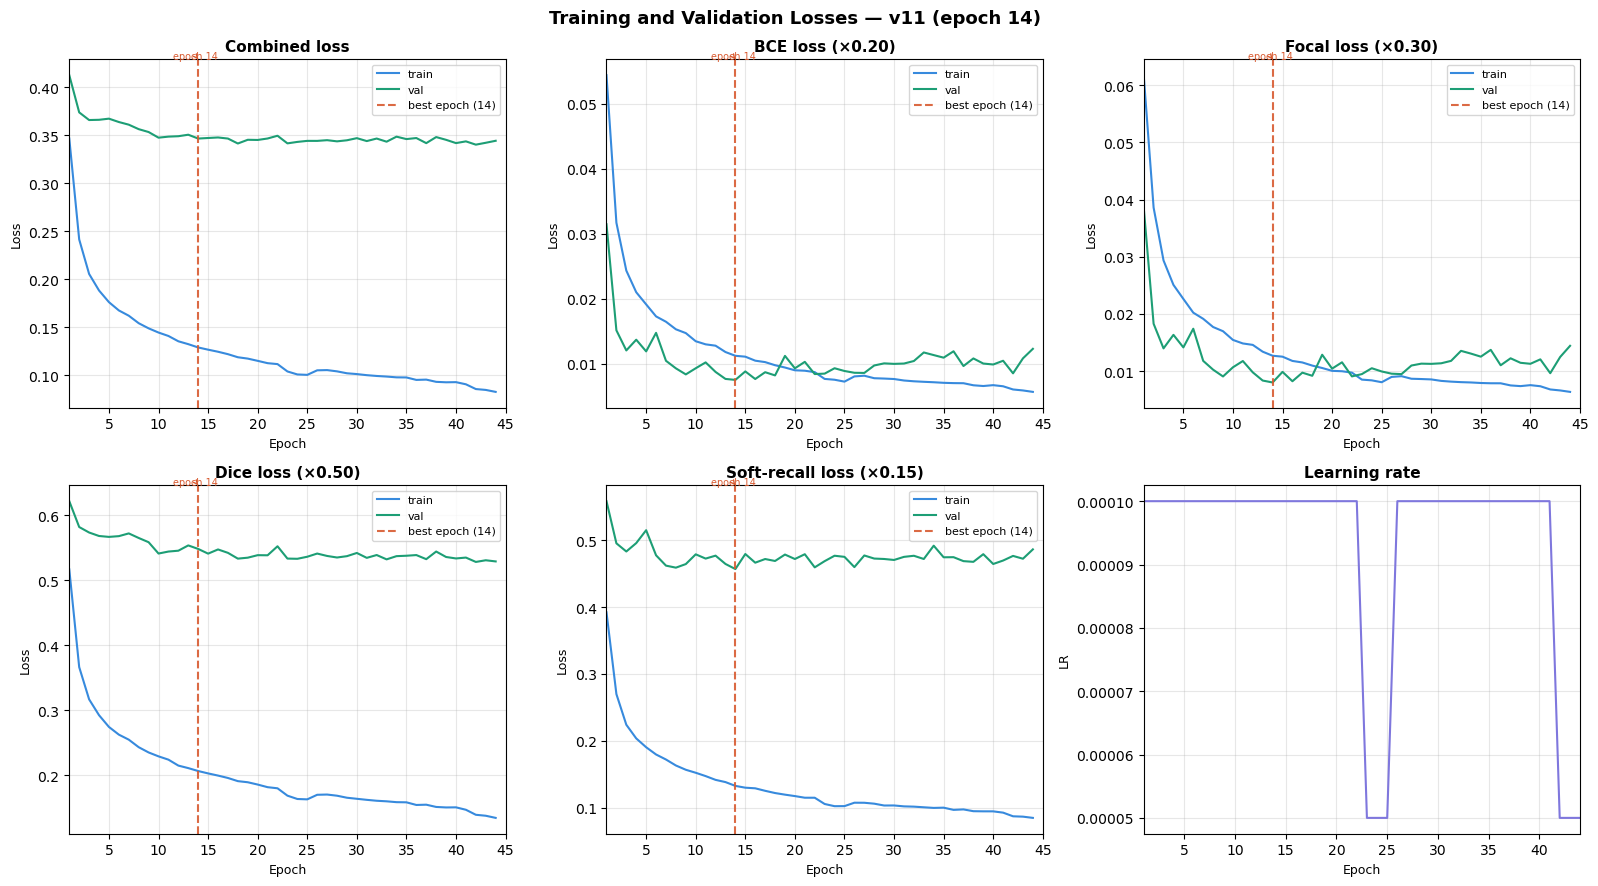

Saved: ./plots/losses.png


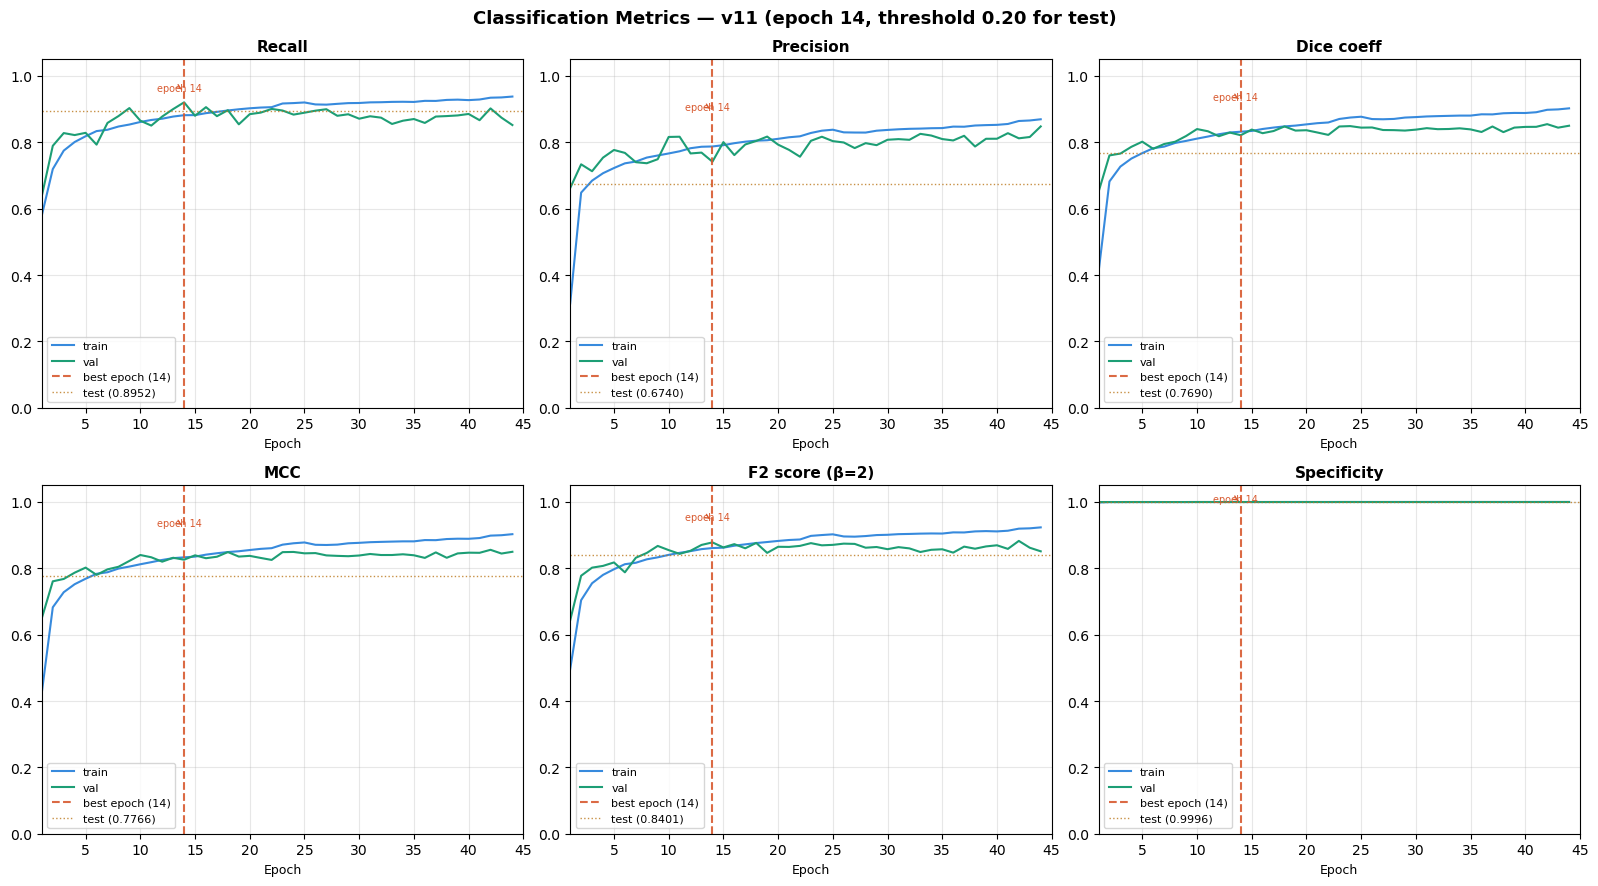

Saved: ./plots/metrics.png


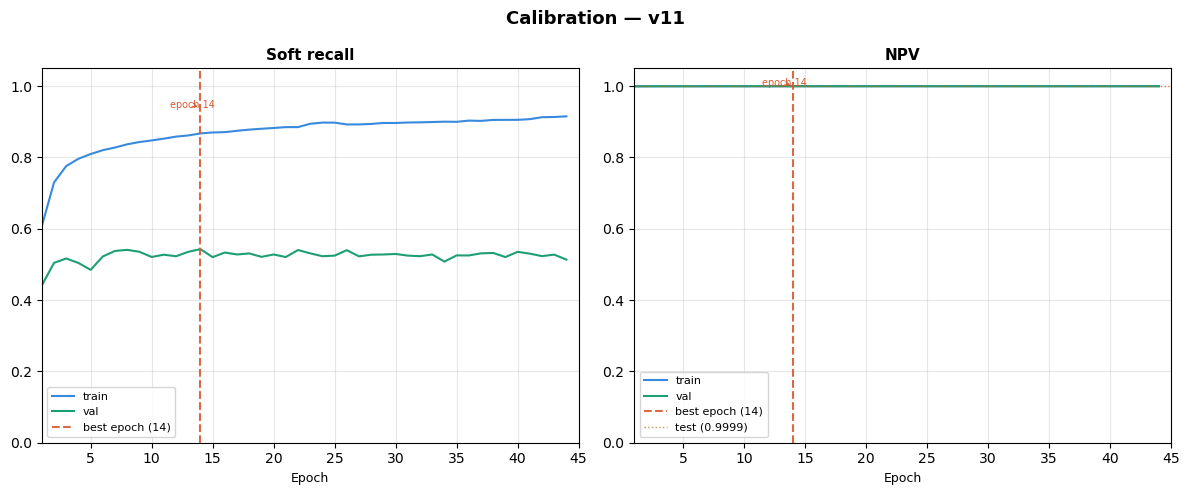

Saved: ./plots/calibration.png


In [6]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

ckpt = torch.load("./checkpoints/last_checkpoint.pth", map_location="cpu")

epochs = list(range(1, ckpt['epoch'] + 1))

train_combined  = ckpt['train_losses_combined']
val_combined    = ckpt['val_losses_combined']
train_bce       = ckpt['train_losses_bce']
val_bce         = ckpt['val_losses_bce']
train_focal     = ckpt['train_losses_focal']
val_focal       = ckpt['val_losses_focal']
train_dice      = ckpt['train_losses_dice']
val_dice        = ckpt['val_losses_dice']
train_softrec   = ckpt['train_losses_softrec']
val_softrec     = ckpt['val_losses_softrec']

train_recalls      = ckpt['train_recalls']
val_recalls        = ckpt['val_recalls']
train_precisions   = ckpt['train_precisions']
val_precisions     = ckpt['val_precisions']
train_dices        = ckpt['train_dices']
val_dices          = ckpt['val_dices']
train_specificities= ckpt['train_specificities']
val_specificities  = ckpt['val_specificities']
train_npvs         = ckpt['train_npvs']
val_npvs           = ckpt['val_npvs']
train_mccs         = ckpt['train_mccs']
val_mccs           = ckpt['val_mccs']
train_f2s          = ckpt['train_f2s']
val_f2s            = ckpt['val_f2s']
train_soft_recalls = ckpt['train_soft_recalls']
val_soft_recalls   = ckpt['val_soft_recalls']
lrs                = ckpt['learning_rates']

# test results at threshold 0.20
TEST = {
    'recall': 0.8952, 'precision': 0.6740, 'dice': 0.7690,
    'f2': 0.8401, 'mcc': 0.7766, 'specificity': 0.9996, 'npv': 0.9999
}
BEST_EPOCH = 14

def plot(ax, train, val, title, ylabel, test_val=None, pct=True):
    ax.plot(epochs, train, label='train', linewidth=1.5, color='#378ADD')
    ax.plot(epochs, val,   label='val',   linewidth=1.5, color='#1D9E75')
    ax.axvline(BEST_EPOCH, color='#D85A30', linewidth=1.5, linestyle='--', alpha=0.9, label=f'best epoch ({BEST_EPOCH})')
    ax.annotate(f'epoch {BEST_EPOCH}',
                xy=(BEST_EPOCH, ax.get_ylim()[1]),
                xytext=(BEST_EPOCH - 2.5, ax.get_ylim()[1]),
                fontsize=7, color='#D85A30',
                arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1))
    if test_val is not None:
        ax.axhline(test_val, color='#BA7517', linewidth=1, linestyle=':', alpha=0.8, label=f'test ({test_val:.4f})')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, len(epochs) + 1) 
    if pct:
        ax.set_ylim(0, 1.05)

os.makedirs('./plots', exist_ok=True)

#Losses
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Training and Validation Losses — v11 (epoch 14)', fontsize=13, fontweight='bold')

plot(axes[0,0], train_combined, val_combined,  'Combined loss','Loss', pct=False)
plot(axes[0,1], train_bce,val_bce,'BCE loss (×0.20)','Loss', pct=False)
plot(axes[0,2], train_focal,val_focal,'Focal loss (×0.30)', 'Loss', pct=False)
plot(axes[1,0], train_dice,val_dice,'Dice loss (×0.50)','Loss', pct=False)
plot(axes[1,1], train_softrec,val_softrec,'Soft-recall loss (×0.15)', 'Loss', pct=False)

# LR on last panel
axes[1,2].plot(epochs, lrs, color='#7F77DD', linewidth=1.5)
axes[1,2].set_title('Learning rate', fontsize=11, fontweight='bold', pad=6)
axes[1,2].set_xlabel('Epoch', fontsize=9)
axes[1,2].set_ylabel('LR', fontsize=9)
axes[1,2].grid(True, alpha=0.3)
axes[1,2].set_xlim(1, len(epochs))

plt.tight_layout()
plt.savefig('./plots/losses.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./plots/losses.png")

#Classification metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Classification Metrics — v11 (epoch 14, threshold 0.20 for test)', fontsize=13, fontweight='bold')

plot(axes[0,0], train_recalls,       val_recalls,       'Recall',       '', TEST['recall'])
plot(axes[0,1], train_precisions,    val_precisions,    'Precision',    '', TEST['precision'])
plot(axes[0,2], train_dices,         val_dices,         'Dice coeff',   '', TEST['dice'])
plot(axes[1,0], train_mccs,          val_mccs,          'MCC',          '', TEST['mcc'])
plot(axes[1,1], train_f2s,           val_f2s,           'F2 score (β=2)', '', TEST['f2'])
plot(axes[1,2], train_specificities, val_specificities, 'Specificity',  '', TEST['specificity'])

plt.tight_layout()
plt.savefig('./plots/metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./plots/metrics.png")

#Calibration
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Calibration — v11', fontsize=13, fontweight='bold')

plot(axes[0], train_soft_recalls, val_soft_recalls, 'Soft recall', '', pct=True)
plot(axes[1], train_npvs,val_npvs,'NPV','', TEST['npv'], pct=True)

plt.tight_layout()
plt.savefig('./plots/calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./plots/calibration.png")

In [8]:
import os
import shutil
import torch

ckpt = torch.load("./checkpoints/best_recall.pth", map_location="cpu")
last = torch.load("./checkpoints/last_checkpoint.pth", map_location="cpu")

dst_dir = "./best_epoch"
os.makedirs(dst_dir, exist_ok=True)

shutil.copy2("./checkpoints/best_recall.pth",
             os.path.join(dst_dir, "epoch_14_recall_0.9204_threshold_0.20.pth"))

e = 14 - 1  

info = f"""UNet3D — best checkpoint
Epoch         : 14 / {last['epoch']} total trained
Early stop    : patience 30, triggered at epoch {last['epoch']}

── val metrics at epoch 14 (threshold 0.50) ──────────────────
Recall        : {ckpt['val_recalls'][e]:.4f}
Precision     : {ckpt['val_precisions'][e]:.4f}
Dice coeff    : {ckpt['val_dices'][e]:.4f}
F2 (β=2)      : {ckpt['val_f2s'][e]:.4f}
MCC           : {ckpt['val_mccs'][e]:.4f}
Specificity   : {ckpt['val_specificities'][e]:.4f}
NPV           : {ckpt['val_npvs'][e]:.4f}
Soft recall   : {ckpt['val_soft_recalls'][e]:.4f}

── val losses at epoch 14 ────────────────────────────────────
Combined      : {ckpt['val_losses_combined'][e]:.4f}
BCE (×0.20)   : {ckpt['val_losses_bce'][e]:.4f}
Focal (×0.30) : {ckpt['val_losses_focal'][e]:.4f}
Dice (×0.50)  : {ckpt['val_losses_dice'][e]:.4f}
SoftRec (×0.15): {ckpt['val_losses_softrec'][e]:.4f}

── train metrics at epoch 14 ─────────────────────────────────
Recall        : {ckpt['train_recalls'][e]:.4f}
Precision     : {ckpt['train_precisions'][e]:.4f}
Dice coeff    : {ckpt['train_dices'][e]:.4f}
F2 (β=2)      : {ckpt['train_f2s'][e]:.4f}
MCC           : {ckpt['train_mccs'][e]:.4f}
Specificity   : {ckpt['train_specificities'][e]:.4f}
NPV           : {ckpt['train_npvs'][e]:.4f}
Soft recall   : {ckpt['train_soft_recalls'][e]:.4f}

── train losses at epoch 14 ──────────────────────────────────
Combined      : {ckpt['train_losses_combined'][e]:.4f}
BCE (×0.20)   : {ckpt['train_losses_bce'][e]:.4f}
Focal (×0.30) : {ckpt['train_losses_focal'][e]:.4f}
Dice (×0.50)  : {ckpt['train_losses_dice'][e]:.4f}
SoftRec (×0.15): {ckpt['train_losses_softrec'][e]:.4f}

── test set results (threshold 0.20) ─────────────────────────
Recall        : 0.8952
Precision     : 0.6740
Dice coeff    : 0.7690
F2 (β=2)      : 0.8401
MCC           : 0.7766
Specificity   : 0.9996
NPV           : 0.9999
TP            : 9406077
FP            : 4549166
FN            : 1100945
TN            : 12512805572

── full val recall history ───────────────────────────────────
{chr(10).join(f"  Epoch {i+1:>3}: {v:.4f}" for i, v in enumerate(last['val_recalls']))}

── full val loss history ─────────────────────────────────────
{chr(10).join(f"  Epoch {i+1:>3}: {v:.4f}" for i, v in enumerate(last['val_losses_combined']))}

── learning rate history ─────────────────────────────────────
{chr(10).join(f"  Epoch {i+1:>3}: {v:.2e}" for i, v in enumerate(last['learning_rates']))}

── model config ──────────────────────────────────────────────
{chr(10).join(f"  {k}: {v}" for k, v in ckpt['config'].items())}

── model ─────────────────────────────────────────────────────
Architecture  : unet3d_3.py
Params        : 51.78M
Threshold     : 0.20 (chosen via val sweep)
Checkpoint    : epoch_14_recall_0.9204_threshold_0.20.pth
"""

with open(os.path.join(dst_dir, "README.txt"), "w") as f:
    f.write(info)

print("Done. Files in ./checkpoints/best_epoch/:")
for f in os.listdir(dst_dir):
    size = os.path.getsize(os.path.join(dst_dir, f)) / 1e6
    print(f"  {f}  ({size:.1f} MB)")

Done. Files in ./checkpoints/best_epoch/:
  epoch_14_recall_0.9204_threshold_0.20.pth  (621.5 MB)
  README.txt  (0.0 MB)
